In [1]:
import matplotlib.pyplot as plt
import numpy as np

# {docnum}`step ref` Figures, Axes and Subplots

In this section we will briefly discuss the underlying objects being used by the pyplot module (Figures and Axes), and how to make subplots.

## Figures

A Matplotlib figure contains plot elements, for example a set of (or multiple sets of) axis, a title etc. Pyplot automatically creates a figure object when you start plotting. 
To manually create your own figures using pyplot, you can use the function:

```python
fig = plt.figure()
```

```{info} When using `plt.plot()` Matplotlib will automatically add the plot to the last figure that was defined.```

If you want to specify the dimensions of the plot, you can create a figure with the first positional or keyword argument:

```python
fig = plt.figure(figsize = (width, height) )
```

where `figsize` (a 2-tuple of width and height) is in inches.


<!-- ```{warning} If you create a figure with the `plt.figure()` function, or the `plt.subplots` function (shown below), then it is good``` -->

```{note} If you want to save a particular figure, then you can call the `figure.savefig()` method from that figure. ```

For more information on the Figure class see the [documentation](https://matplotlib.org/api/_as_gen/matplotlib.figure.Figure.html#matplotlib.figure.Figure).

## Axes

The Axes object contains all the elements of a sub-plot, including the x/y ticks, plotting functions, etc. Axes are usually generated by the Figure methods or other functions like `plt.subplots()` (discussed below).

For more information on the Axes class see the [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.html).

## Subplots

If you want to create a plot with multiple axis (sub-plots), then there are two major ways to do that:

### `fig.add_subplot()`

One way to add subplots is by creating a figure and calling the `fig.add_subplot()` method to add an axes to it with the call signature:

```python
fig.add_subplot(nrows, ncols, index)
```

where `nrows` and `ncols` are the total number of rows and columns of axis and `index` is the position on the grid of axes (starting from 1). This method returns the Axes object added.

Consider the plot with two rows and a single column:

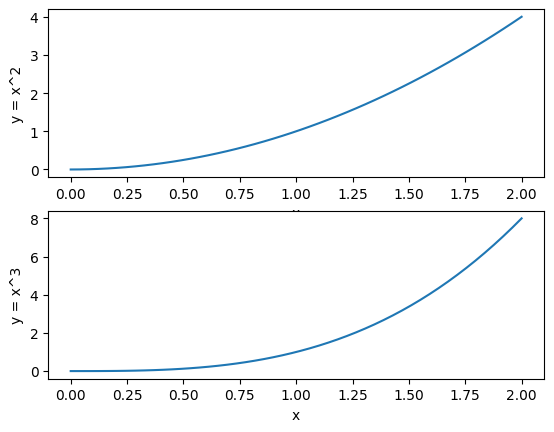

In [2]:
x = np.linspace(0, 2)


fig = plt.figure()

#Top axis
ax0 = fig.add_subplot(2, 1, 1)
ax0.plot(x , x**2)
ax0.set_xlabel('x') #Note `set_xlabel` instead of `xlabel`
ax0.set_ylabel('y = x^2')

#Bottom axis
ax1 = fig.add_subplot(2, 1, 2)
ax1.plot(x, x*x*x)
ax1.set_xlabel('x')
ax1.set_ylabel('y = x^3')

plt.show()

Refer to the [documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.figure.Figure.html#matplotlib.figure.Figure.add_subplot) for additional options.

### `plt.subplots()`

An alternative way to create subplots is to use the `plt.subplots()` function which returns the figure object and a tuple of axis. The call signature is:

```python
plt.subplots(nrows = 1, ncols = 1)
```

where `nrows` and `ncols` are the number of rows an columns as before.

Let's recreate the previous plot using this function:

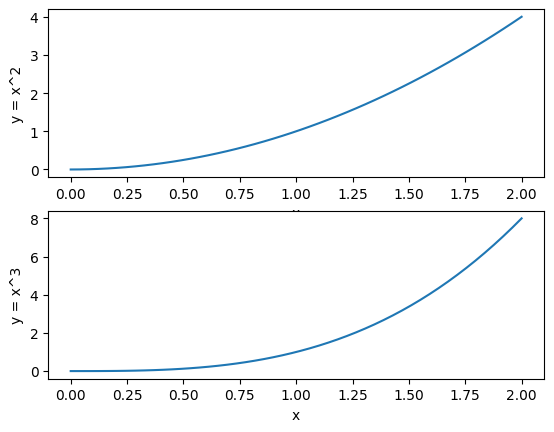

In [3]:
x = np.linspace(0, 2)

fig, ax = plt.subplots(2, 1)

#Top axis
ax[0].plot(x , x**2)
ax[0].set_xlabel('x') #Note `set_xlabel` instead of `xlabel`
ax[0].set_ylabel('y = x^2')

#Bottom axis
ax[1].plot(x, x*x*x)
ax[1].set_xlabel('x')
ax[1].set_ylabel('y = x^3')

plt.show()

A couple of additional keyword arguments are `sharex` and `sharey`. These take boolean values. If true the subplots will share the relevant axis's ticks. For example:

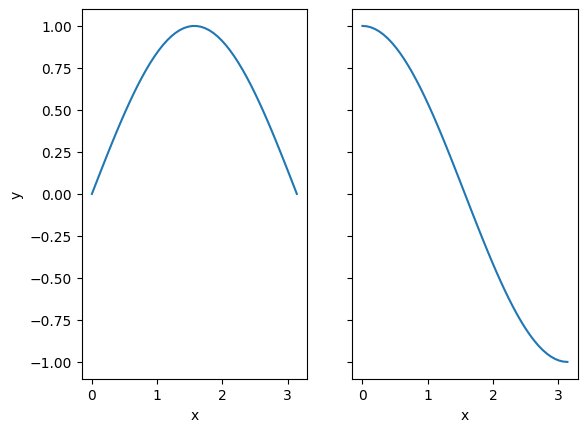

In [4]:
x = np.linspace(0, np.pi)

fig, ax = plt.subplots(1, 2, sharey = True)

ax[0].plot(x, np.sin(x))
ax[0].set_xlabel('x')

ax[1].plot(x, np.cos(x))
ax[1].set_xlabel('x')

ax[0].set_ylabel('y') #You can set this for the other axis

plt.show()

Refer to the [documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.subplots.html) for additional options.

### Tight Layout

When working with subplots, you will often come across the problem of axes titles and labels overlapping. For example:

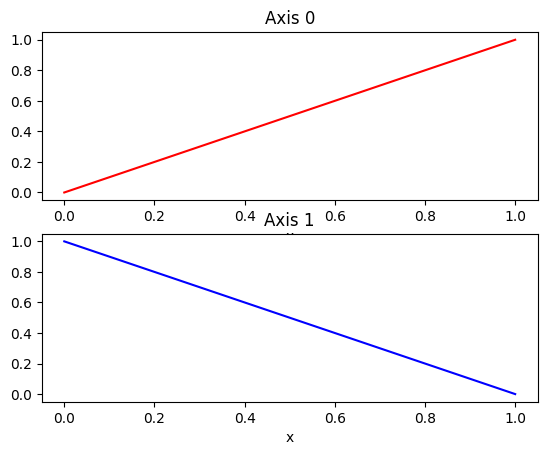

In [5]:
fig, ax = plt.subplots(2, 1)

ax[0].plot((0, 1), color='red')
ax[0].set_title('Axis 0')
ax[0].set_xlabel('x')

ax[1].plot((1, 0), color='blue')
ax[1].set_title('Axis 1')
ax[1].set_xlabel('x')

plt.show()

While you can change the layout settings of your plot manually, there is an automated solution provided, the function `plt.tight_layout()`. If called from `pyplot`, this will affect the current figure, alternatively it can be called as a method from a figure of choice. Applying this to our example above:

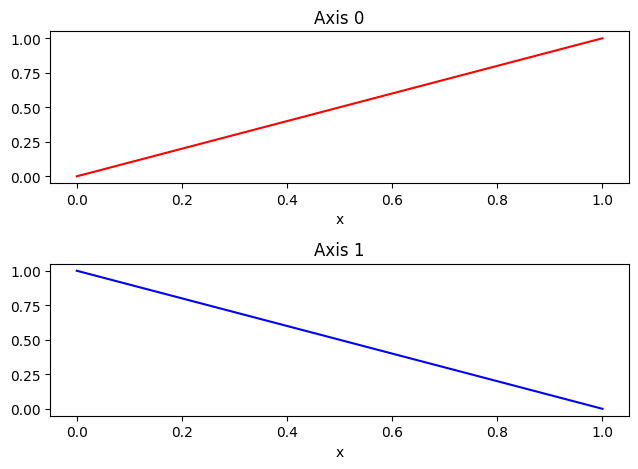

In [6]:
fig, ax = plt.subplots(2, 1)

ax[0].plot((0, 1), color='red')
ax[0].set_title('Axis 0')
ax[0].set_xlabel('x')

ax[1].plot((1, 0), color='blue')
ax[1].set_title('Axis 1')
ax[1].set_xlabel('x')

fig.tight_layout()

plt.show()

### Subplots With Multiple Rows and Columns

All the subplots above have either a single column and multiple rows, or a single row and multiple columns. For both of these cases the `plt.subplots()` function returns a one-dimensional array for the axes. If you specify multiple rows and columns, then the array of axes is two dimensional, with the first index corresponding to the rows and the second index corresponding to the columns. For example: 


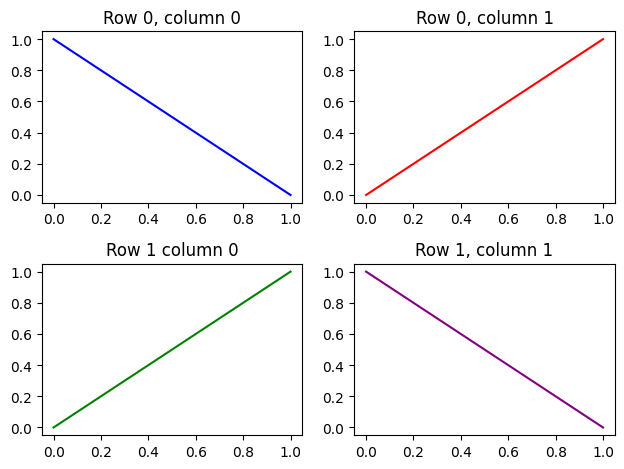

In [7]:
fig, ax = plt.subplots(2, 2)

ax[0, 0].set_title('Row 0, column 0')
ax[0, 0].plot((1, 0), color='blue')

ax[0, 1].set_title('Row 0, column 1')
ax[0, 1].plot((0,1), color='red')

ax[1, 0].set_title('Row 1 column 0')
ax[1, 0].plot((0,1), color='green')

ax[1, 1].set_title('Row 1, column 1')
ax[1, 1].plot((1, 0), color='purple')

fig.tight_layout()

plt.show()

### Using Subplots For General Plots

The subplot functions above are also used in general practice to create single axis plots, due to the ability to create a reference to the axis, which grants further customization. Simply:

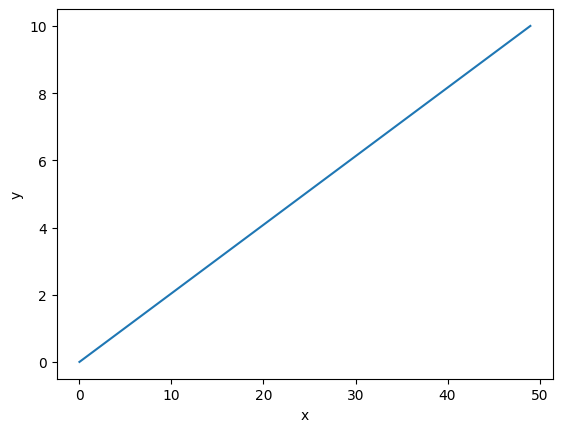

In [8]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(np.linspace(0, 10))
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.show()